## Predictive Maintenance & Machine Anomaly Detection Using Isolation Forest

## *Problem Statement*

Manufacturing industries rely on machines and equipment that operate continuously under different operating conditions. Unexpected machine failures can lead to production downtime, maintenance costs, equipment damage, and loss of productivity.

Traditional maintenance approaches face several challenges:

- Reactive maintenance is performed only after a machine fails

- Preventive maintenance may result in unnecessary maintenance costs

- Machine operating conditions can change over time

- Abnormal machine behavior may occur before an actual failure

- Hence an unsupervised anomaly detection approach can be used to identify unusual machine operating conditions.

🔹 Goal: Detect abnormal machine operating conditions without relying directly on machine failure labels using Isolation Forest.

## *Objectives of the Project*

1. Detect abnormal machine operating conditions using an unsupervised learning model

2. Identify anomalies in machine sensor data

3. Analyze machine operating patterns and sensor behavior

4. Build a robust and scalable predictive maintenance monitoring system

5. Identify machines that may require maintenance based on abnormal behavior

6. Generate actionable maintenance insights from detected machine anomalies

## *Dataset Description*

The dataset represents industrial machine operating conditions, where each row corresponds to one machine observation.

Dataset Characteristics:

- The dataset contains machine operating and sensor measurements including air temperature, process temperature, rotational speed, torque, and tool wear.

- The dataset also contains machine failure indicators and different failure modes such as tool wear failure, heat dissipation failure, power failure, overstrain failure, and random failure.

- The sensor measurements can be used to identify unusual machine operating conditions using an unsupervised anomaly detection approach.

- Isolation Forest is used to detect anomalous machine behavior without using the machine failure columns as input features.

## *Dataset Column Description*

| Column Name | Description |
|------------|-------------|
| UDI | Unique identifier for each machine observation |
| Product ID | Unique identifier for the machine/product |
| Type | Product quality/type category of the machine |
| Air temperature [K] | Ambient air temperature measured in Kelvin |
| Process temperature [K] | Temperature of the machine process measured in Kelvin |
| Rotational speed [rpm] | Rotational speed of the machine measured in revolutions per minute |
| Torque [Nm] | Torque generated by the machine measured in Newton-metres |
| Tool wear [min] | Accumulated tool usage or wear measured in minutes |
| Machine failure | Indicates whether a machine failure occurred |
| TWF | Tool Wear Failure indicator |
| HDF | Heat Dissipation Failure indicator |
| PWF | Power Failure indicator |
| OSF | Overstrain Failure indicator |
| RNF | Random Failure indicator |

## *Importing Libraries*

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

## *Data Loading*

In [2]:
df = pd.read_csv(r"C:\Users\DELL\.ipynb_checkpoints\Desktop\ML\Predictive Maintenance Anomaly\Predictive Maintenance .csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## *Exploratory Data Analysis*

In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [4]:
df.shape

(10000, 14)

In [5]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## *Dropping Unwanted Columns*

In [9]:
drop_cols = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

df_model = df.drop(columns=drop_cols)

## *Encoding*

In [10]:
categorical_cols = df_model.select_dtypes(include="object").columns

categorical_cols

Index(['Type'], dtype='object')

In [11]:
le = LabelEncoder()

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

## *Feature Engineering*

In [12]:
df_model["Temperature_Difference"] = (
    df_model["Process temperature [K]"] -
    df_model["Air temperature [K]"]
)

df_model["Power_Load"] = (
    df_model["Rotational speed [rpm]"] *
    df_model["Torque [Nm]"]
)

df_model["Torque_Per_RPM"] = (
    df_model["Torque [Nm]"] /
    (df_model["Rotational speed [rpm]"] + 1)
)

In [13]:
df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature_Difference,Power_Load,Torque_Per_RPM
0,2,298.1,308.6,1551,42.8,0,10.5,66382.8,0.027577
1,1,298.2,308.7,1408,46.3,3,10.5,65190.4,0.032860
2,1,298.1,308.5,1498,49.4,5,10.4,74001.2,0.032955
3,1,298.2,308.6,1433,39.5,7,10.4,56603.5,0.027545
4,1,298.2,308.7,1408,40.0,9,10.5,56320.0,0.028389


In [14]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## *Scaling*

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_model)

In [16]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=df_model.columns,
    index=df_model.index
)

X_scaled_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature_Difference,Power_Load,Torque_Per_RPM
0,1.333889,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0.498849,0.629443,0.079307
1,-0.332223,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0.498849,0.512456,0.677561
2,-0.332223,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0.398954,1.376889,0.688333
3,-0.332223,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0.398954,-0.330009,0.075685
4,-0.332223,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0.498849,-0.357824,0.171217


## *EDA VISUALS*

## *Air Temperature Distribution*

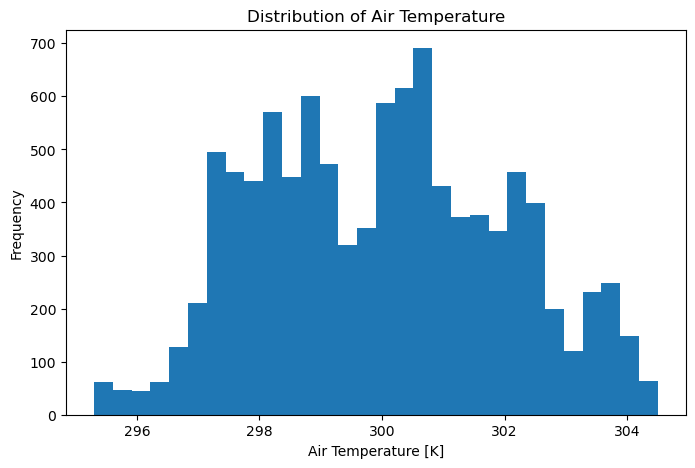

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Air temperature [K]"], bins=30)

plt.title("Distribution of Air Temperature")
plt.xlabel("Air Temperature [K]")
plt.ylabel("Frequency")

plt.show()

## *Rotational Speed Distribution*

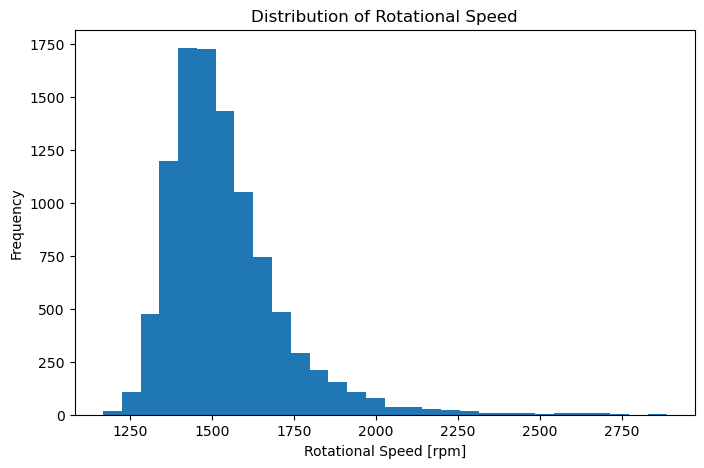

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Rotational speed [rpm]"], bins=30)

plt.title("Distribution of Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Frequency")

plt.show()

## *Torque Distribution*

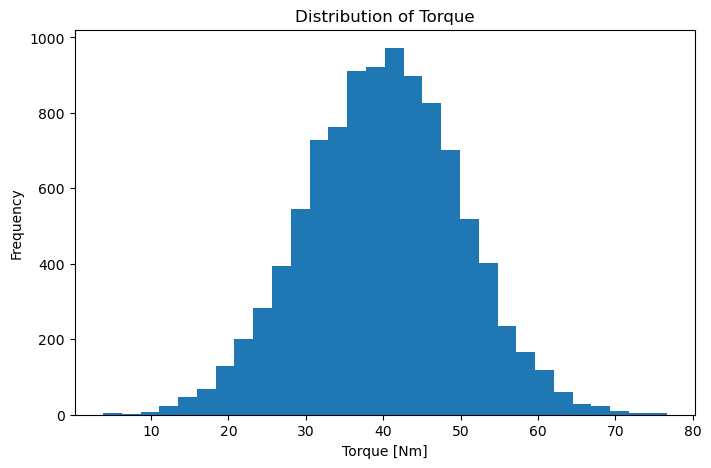

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["Torque [Nm]"], bins=30)

plt.title("Distribution of Torque")
plt.xlabel("Torque [Nm]")
plt.ylabel("Frequency")

plt.show()

## *Tool Wear Distribution*

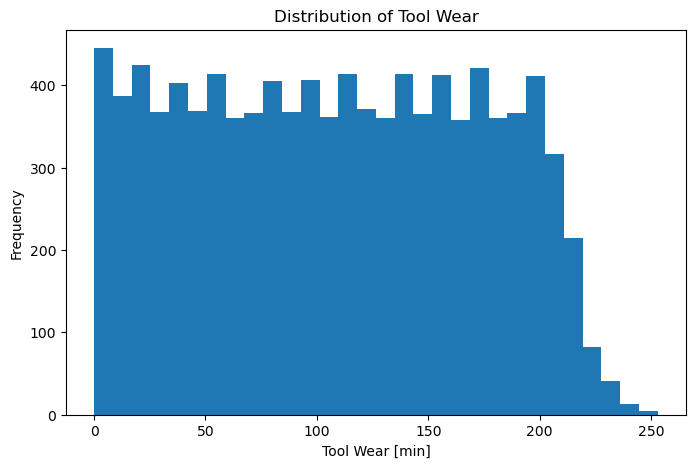

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Tool wear [min]"], bins=30)

plt.title("Distribution of Tool Wear")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Frequency")

plt.show()

## *Boxplot of Torque (Outliers)*

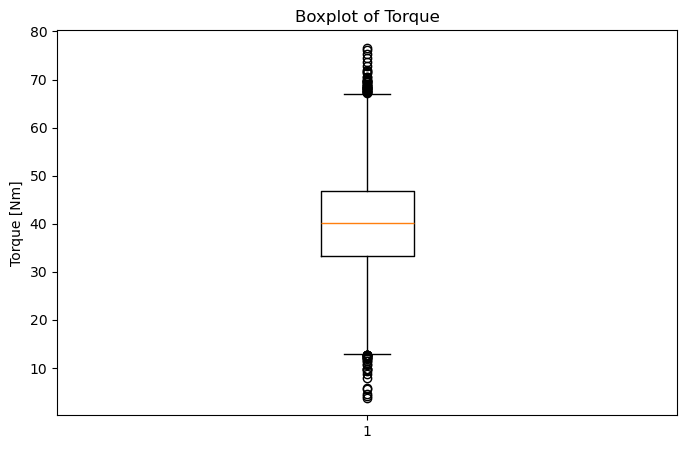

In [21]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Torque [Nm]"])

plt.title("Boxplot of Torque")
plt.ylabel("Torque [Nm]")

plt.show()

## *Boxplot of Tool Wear (Outliers)*

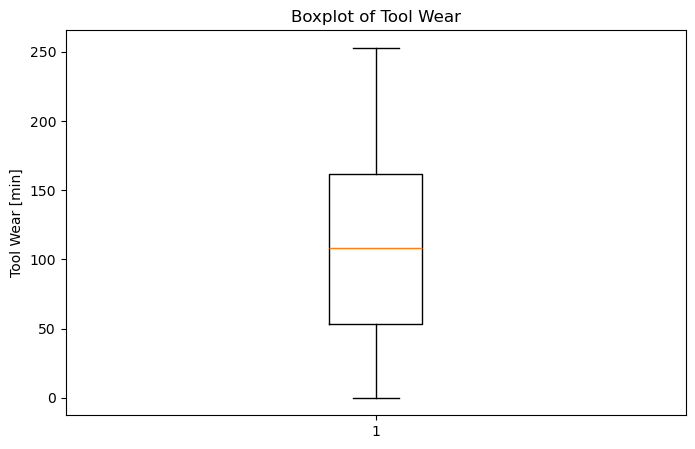

In [22]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Tool wear [min]"])

plt.title("Boxplot of Tool Wear")
plt.ylabel("Tool Wear [min]")

plt.show()

## *Correlation Heatmap*

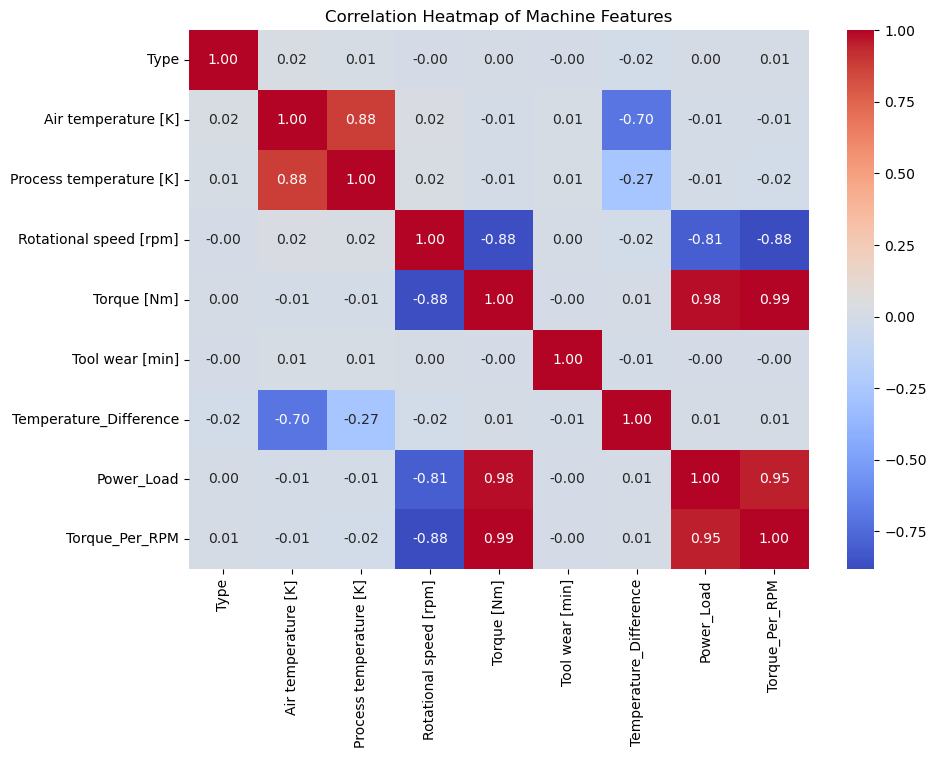

In [23]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_model.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Machine Features")

plt.show()

## *Temperature vs Tool Wear*

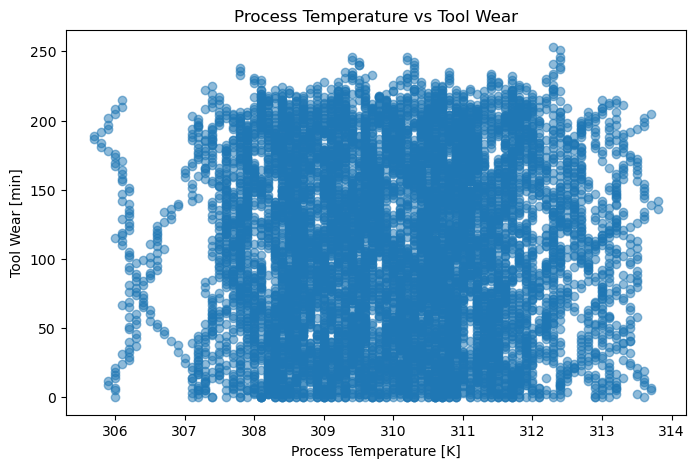

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Process temperature [K]"],
    df["Tool wear [min]"],
    alpha=0.5
)

plt.title("Process Temperature vs Tool Wear")
plt.xlabel("Process Temperature [K]")
plt.ylabel("Tool Wear [min]")

plt.show()

## *Torque vs Rotational Speed*

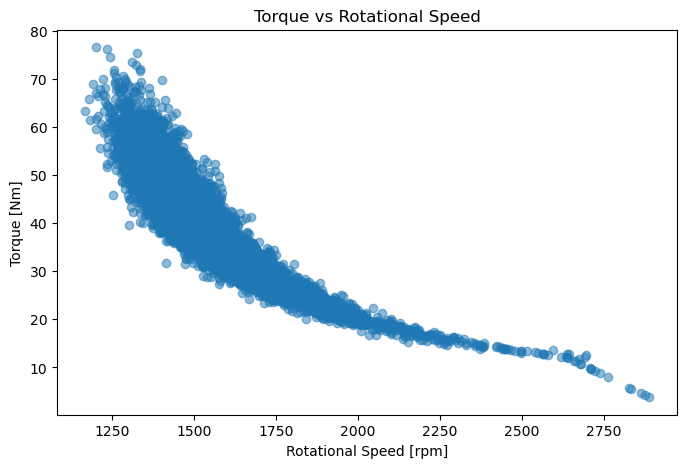

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Rotational speed [rpm]"],
    df["Torque [Nm]"],
    alpha=0.5
)

plt.title("Torque vs Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")

plt.show()

## *Isolation Forest*

Isolation Forest is an unsupervised machine learning algorithm used to identify anomalous observations.

The algorithm isolates observations by randomly selecting features and split values. Anomalous observations are generally isolated faster because they are different from the majority of observations.

In this project, Isolation Forest learns patterns from machine operating and sensor data without using the machine failure labels.

🔹 Goal: Identify machines operating under abnormal conditions before or around potential machine failures.

## *Isolation Forest Model Building* 

In [26]:
iso_forest = IsolationForest(n_estimators=100,contamination=0.02,random_state=42)
iso_forest.fit(X_scaled) #Model Training

IsolationForest(contamination=0.02, random_state=42)

In [27]:
anomaly_pred = iso_forest.predict(X_scaled)
df["Anomaly"] = np.where(anomaly_pred == -1, 1, 0)

In [28]:
df["AnomalyScore"] = iso_forest.decision_function(X_scaled)

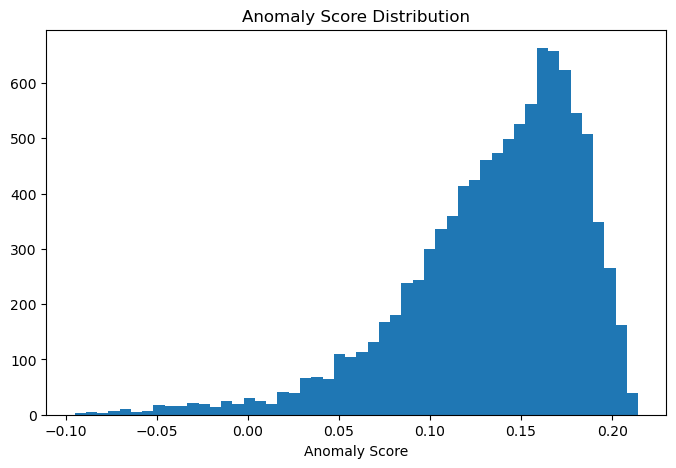

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["AnomalyScore"], bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.show()

In [30]:
df.sort_values("AnomalyScore").head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Anomaly,AnomalyScore
4419,4420,M19279,M,302.6,310.2,2676,10.8,84,1,0,0,1,0,0,1,-0.095295
8114,8115,H37528,H,300.4,311.8,2496,13.5,5,0,0,0,0,0,0,1,-0.094069
1095,1096,L48275,L,296.9,307.5,2721,9.3,18,1,0,0,1,0,0,1,-0.093268
847,848,L48027,L,296.4,307.4,2833,5.6,213,1,0,0,1,0,0,1,-0.088579
4997,4998,M19857,M,303.6,312.8,2659,11.4,26,1,0,0,1,0,0,1,-0.087640


In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

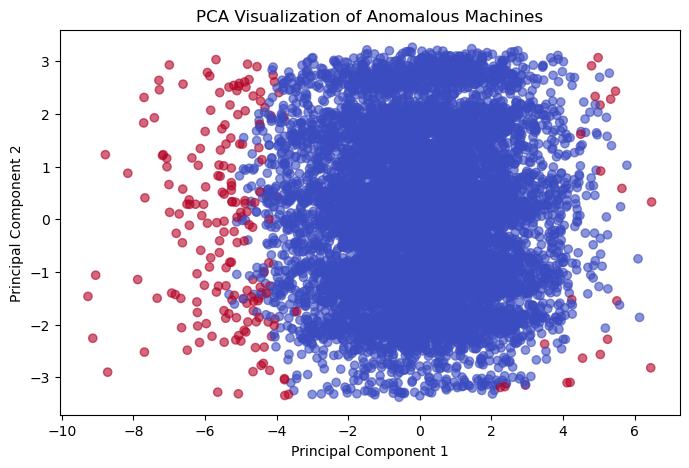

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Anomaly"],
    cmap="coolwarm",
    alpha=0.6
)

plt.title("PCA Visualization of Anomalous Machines")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [33]:
top_anomalies = df.sort_values("AnomalyScore").head(10)
top_anomalies

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Anomaly,AnomalyScore
4419,4420,M19279,M,302.6,310.2,2676,10.8,84,1,0,0,1,0,0,1,-0.095295
8114,8115,H37528,H,300.4,311.8,2496,13.5,5,0,0,0,0,0,0,1,-0.094069
1095,1096,L48275,L,296.9,307.5,2721,9.3,18,1,0,0,1,0,0,1,-0.093268
847,848,L48027,L,296.4,307.4,2833,5.6,213,1,0,0,1,0,0,1,-0.088579
4997,4998,M19857,M,303.6,312.8,2659,11.4,26,1,0,0,1,0,0,1,-0.087640
887,888,H30301,H,295.7,306.2,2161,16.5,105,0,0,0,0,0,0,1,-0.087551
3867,3868,M18727,M,302.7,311.6,2709,9.7,2,1,0,0,1,0,0,1,-0.086003
4762,4763,M19622,M,303.7,312.0,2663,11.4,71,1,0,0,1,0,0,1,-0.085574
903,904,L48083,L,295.7,306.2,2270,14.6,149,1,0,0,1,0,0,1,-0.078124
4296,4297,L51476,L,301.8,310.2,2825,5.8,215,1,0,0,1,0,0,1,-0.077844


In [34]:
threshold = df["AnomalyScore"].quantile(0.02)

df["AnomalyLabel"] = (df["AnomalyScore"] <= threshold).astype(int)

df["AnomalyLabel"].value_counts()

AnomalyLabel
0    9800
1     200
Name: count, dtype: int64

In [35]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Anomaly,AnomalyScore,AnomalyLabel
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,0.132741,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,0.166252,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,0.144314,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,0.166948,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,0.163138,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,0,0.110446,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,0,0.096068,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,0,0.140410,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,0,0.117409,0


## *CLASSIFICATION*

In [36]:
X = df.drop(columns=[
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
    "Anomaly",
    "AnomalyScore"
])

y = df["Machine failure"]

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["Type"] = le.fit_transform(X["Type"])

In [38]:
X["Type"].value_counts()

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

In [39]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [41]:
print(X_resampled.shape)
print(y_resampled.shape)

(19322, 7)
(19322,)


SMOTE was used to balance machine failure and non-failure samples to avoid biased learning.

In [42]:
print(X.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'AnomalyLabel']


In [43]:
X.columns = X.columns.astype(str)

X.columns = (
    X.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

In [44]:
print(X.columns.tolist())

['Type', 'Air temperature _K_', 'Process temperature _K_', 'Rotational speed _rpm_', 'Torque _Nm_', 'Tool wear _min_', 'AnomalyLabel']


In [45]:
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.3,
    random_state=42
)

## *RANDOM FOREST CLASSIFIER*

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2752  149]
 [  74 2822]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2901
           1       0.95      0.97      0.96      2896

    accuracy                           0.96      5797
   macro avg       0.96      0.96      0.96      5797
weighted avg       0.96      0.96      0.96      5797



In [48]:
def predict_machine_failure(new_machine):
    scaled = scaler.transform(new_machine)
    anomaly_score = iso_forest.decision_function(scaled)
    failure_pred = rf.predict(new_machine)
    return failure_pred, anomaly_score

## *XG BOOST*

In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

## *LIGHTGBM*

In [50]:
!pip install lightgbm
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6765, number of negative: 6760
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 13525, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500185 -> initscore=0.000739
[LightGBM] [Info] Start training from score 0.000739
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMClassifier(colsample_bytree=0.8, max_depth=6, n_estimators=200,
               random_state=42, subsample=0.8)

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Random Forest
[[2752  149]
 [  74 2822]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2901
           1       0.95      0.97      0.96      2896

    accuracy                           0.96      5797
   macro avg       0.96      0.96      0.96      5797
weighted avg       0.96      0.96      0.96      5797


XGBoost
[[2808   93]
 [  27 2869]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2901
           1       0.97      0.99      0.98      2896

    accuracy                           0.98      5797
   macro avg       0.98      0.98      0.98      5797
weighted avg       0.98      0.98      0.98      5797


LightGBM
[[2834   67]
 [  22 2874]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2901
           1       0.98      0.99      0.98      2896

    accuracy                           0.98      5797
   macro avg 

## *FEATURE IMPORTANCE*

In [52]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
4,Torque _Nm_,0.311435
3,Rotational speed _rpm_,0.281015
5,Tool wear _min_,0.202044
1,Air temperature _K_,0.081467
2,Process temperature _K_,0.051648
0,Type,0.045950
6,AnomalyLabel,0.026441


## *RANDOM FOREST - FEATURE IMPORTANCE*

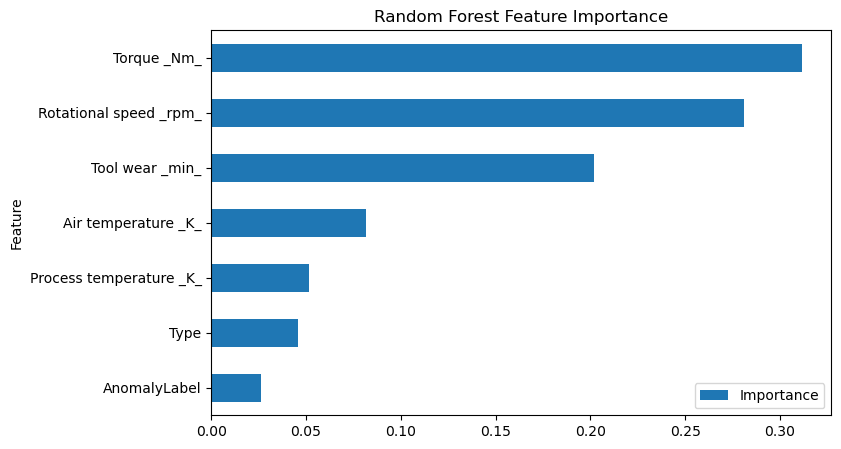

In [53]:
rf_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    title="Random Forest Feature Importance",
    figsize=(8,5)
)

plt.gca().invert_yaxis()
plt.show()

## *XGB CLASSIFIER - FEATURE IMPORTANCE*

In [54]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(10)

,Feature,Importance
4,Torque _Nm_,0.274067
3,Rotational speed _rpm_,0.232520
5,Tool wear _min_,0.190967
0,Type,0.143626
1,Air temperature _K_,0.070460
2,Process temperature _K_,0.060145
6,AnomalyLabel,0.028214


## *LGBM CLASSIFIER - FEATURE IMPORTANCE*

In [55]:
lgbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm.feature_importances_
}).sort_values(by="Importance", ascending=False)

lgbm_importance.head(10)

,Feature,Importance
2,Process temperature _K_,1323
5,Tool wear _min_,1111
1,Air temperature _K_,1024
3,Rotational speed _rpm_,1009
4,Torque _Nm_,994
0,Type,222
6,AnomalyLabel,14


## *CONCLUSION*

This project developed a predictive maintenance and machine anomaly detection framework using Isolation Forest to identify abnormal machine operating conditions. Isolation Forest was selected because it can detect unusual machine behavior without requiring machine failure labels during the anomaly detection stage.

Supervised models such as Random Forest, XGBoost, and LightGBM were later applied for machine failure prediction using the actual machine failure labels. SMOTE was used to address the imbalance between machine failure and non-failure observations. PCA was also used to visualize the machine operating patterns and detected anomalies.

Feature importance analysis was performed to identify the most influential machine operating factors for failure prediction. Overall, the hybrid approach combining Isolation Forest for anomaly detection with supervised classifiers for machine failure prediction provides a robust framework for predictive maintenance and proactive machine monitoring.